Cloning into 'git'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 90 (delta 36), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (90/90), 2.05 MiB | 10.56 MiB/s, done.
Resolving deltas: 100% (36/36), done.


/tmp/ipykernel_819/3052578550.py:321: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


[1.10572525 1.04530237 1.43890205 1.62538882]
[[ 0.          0.        ]
 [ 1.42792083  0.55432347]
 [ 2.58669023  1.00963871]
 [ 3.4837163  -1.03463413]
 [ 5.25        1.        ]]
245.94695783557327


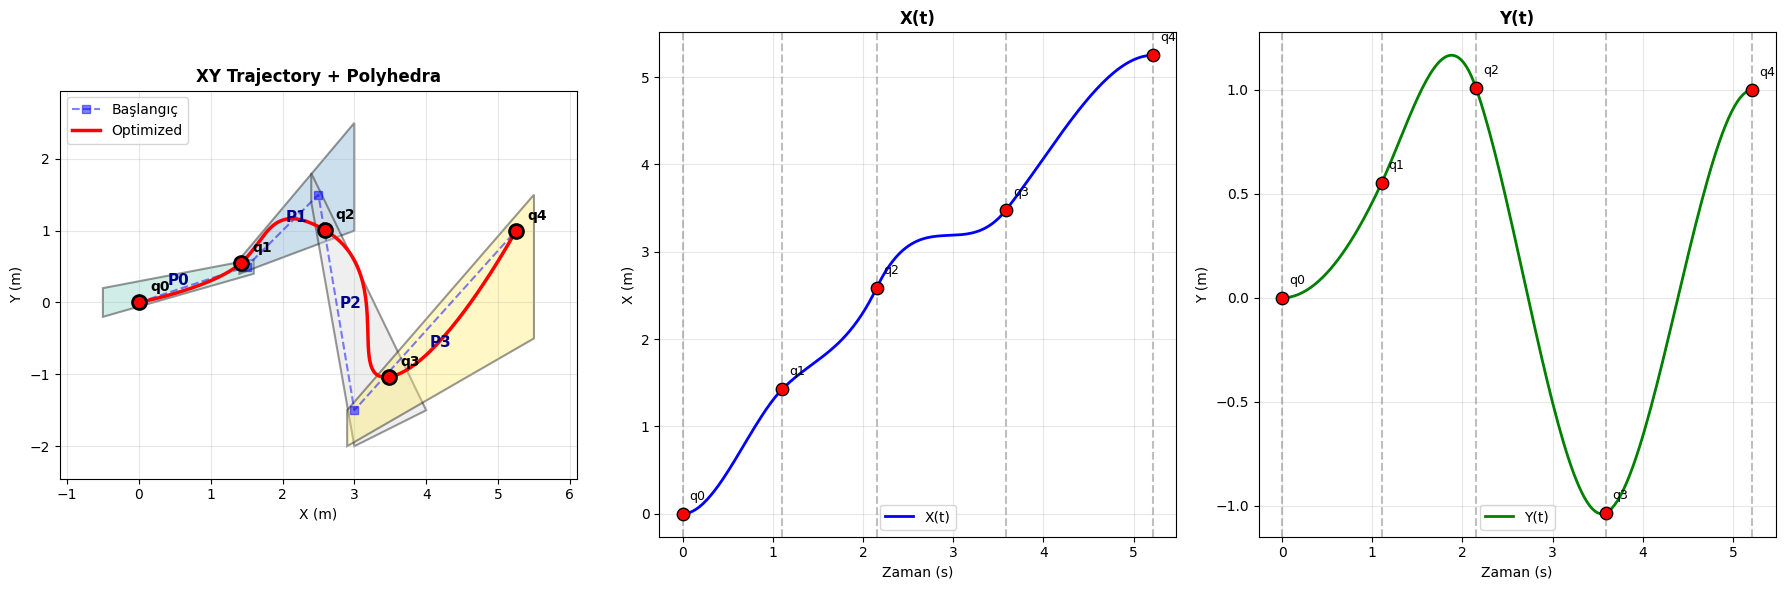

In [1]:
import os
if not os.path.exists("git/main.py"):
    !rm -rfd sample_data
    !rm -rfd git
    !git clone --single-branch --branch Util https://github.com/DemirDorukDilek/DDoP git



import sys
top_level_container_dir = "git/"
if top_level_container_dir not in sys.path:
    sys.path.insert(0, top_level_container_dir)
from Utils import visualize_trajectory_2d,polygon_to_polyhedron,visualize_state,visualize_results_2d
from DDoP import DDoP



import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.optimize import minimize
import scipy.special

class DDoPnD:

    def __init__(self,Ts,waypoints,polyhedra,fix_times=False,fix_waypoints=False,S=4):
        self.save = Ts.copy(),waypoints.copy(),polyhedra.copy()
        self.Ts = Ts
        self.waypoints = waypoints
        self.fix_times = fix_times
        self.fix_waypoints = fix_waypoints
        self.S = S
        self.dims = [np.array(dim) for dim in zip(*waypoints)]
        self.dim = len(self.dims)
        self.M = len(Ts)
        self.opt = [DDoP(Ts.copy(),dim,True,True,S) for dim in self.dims]
        self.polyhedra = polyhedra

        self.rho_t = 32.0
        self.rho_v = 128.0
        self.rho_a = 128.0
        self.v_max = 4.0
        self.a_max = 5.0

        self.pakka = 1.0

        self.iter = 0

    def reset(self):
        self.__init__(*self.save,self.fix_times,self.fix_waypoints,self.S)

    def _unpack(self,x):
        idx = 0
        if not self.fix_times:
            self.Ts = x[idx:idx+self.M]
            idx += self.M
        if not self.fix_waypoints:
            n_inner = self.M-1
            for i in range(self.dim):
                self.dims[i] = np.concatenate([[self.dims[i][0]], x[idx:idx+n_inner], [self.dims[i][-1]]])
                idx = idx+n_inner
            self.waypoints = np.column_stack(self.dims)



    def _update_sub_optimizers(self):
        for idx,opt in enumerate(self.opt):
            opt.Ts = self.Ts.copy()
            opt.checkpoints = self.dims[idx].copy()
            opt._update_dconst_kappa()

    def g(self,x):
        return np.power(max(x,0),3)
    def dgdx(self,x):
        return 3*np.power(max(x,0),2)
    def _compute_V(self, i):
        """v_i = (q_{i+1} - q_{i-1}) / (T_i + T_{i+1})"""
        q_prev = self.waypoints[i - 1]
        q_next = self.waypoints[i + 1]
        T_sum = self.Ts[i - 1] + self.Ts[i]
        return (q_next - q_prev) / T_sum

    def _compute_a(self, i):
        """a_i = 2 * (v_out - v_in) / (T_i + T_{i+1})"""
        q_prev = self.waypoints[i - 1]
        q_curr = self.waypoints[i]
        q_next = self.waypoints[i + 1]
        T_prev = self.Ts[i - 1]
        T_next = self.Ts[i]

        v_in = (q_curr - q_prev) / T_prev
        v_out = (q_next - q_curr) / T_next
        T_sum = T_prev + T_next

        return 2.0 * (v_out - v_in) / T_sum

    def _compute_gradJ_D_v(self):
        """
        v_i = (q_{i+1} - q_{i-1}) / (T_{i-1} + T_i)
        ||v_i||² = ||q_{i+1} - q_{i-1}||² / (T_{i-1} + T_i)²

        J_v = ρ_v * Σ g(||v_i||² - v_max²)
        """
        grad_T = np.zeros(self.M)
        grad_q = np.zeros((self.dim, self.M - 1))

        for i in range(1, self.M):
            q_prev = self.waypoints[i - 1]
            q_curr = self.waypoints[i]
            q_next = self.waypoints[i + 1]
            T_sum = self.Ts[i - 1] + self.Ts[i]
            T_sum_sq = np.power(T_sum,2)

            diff = q_next - q_prev
            diff_sq = np.sum(np.power(diff,2))
            v_sq = diff_sq /T_sum_sq

            gp = self.dgdx(v_sq - np.power(self.v_max, 2))

            if gp > 0:
                # ∂||v||²/∂T = -2 * ||diff||² / T_sum³
                dv_sq_dT = -2.0 * diff_sq / np.power(T_sum,3)

                # ∂J_v/∂T_{i-1} and ∂J_v/∂T_i
                grad_T[i - 1] += self.rho_v * gp * dv_sq_dT
                grad_T[i] += self.rho_v * gp * dv_sq_dT

                # ∂||v||²/∂q_{i-1} = -2 * diff / T_sum²
                # ∂||v||²/∂q_{i+1} = +2 * diff / T_sum²
                dv_sq_dq = 2.0 * diff / T_sum_sq

                # if q_{i-1} inner point
                if i - 1 >= 1:
                    grad_q[:, i - 2] += self.rho_v * gp * (-dv_sq_dq)

                # if q_{i+1} inner point
                if i + 1 <= self.M - 1:
                    grad_q[:, i] += self.rho_v * gp * dv_sq_dq

        return grad_T, grad_q

    def _compute_gradJ_D_a(self):
        """
        a_i = 2 * (v_out - v_in) / T_sum
        where:
            v_in = (q_i - q_{i-1}) / T_{i-1}
            v_out = (q_{i+1} - q_i) / T_i
            T_sum = T_{i-1} + T_i
        """
        grad_T = np.zeros(self.M)
        grad_q = np.zeros((self.dim, self.M - 1))

        for i in range(1, self.M):
            q_prev = self.waypoints[i - 1]
            q_curr = self.waypoints[i]
            q_next = self.waypoints[i + 1]
            T_prev = self.Ts[i - 1]
            T_next = self.Ts[i]
            T_sum = T_prev + T_next
            T_sum_sq = np.power(T_sum,2)

            v_in = (q_curr - q_prev) / T_prev
            v_out = (q_next - q_curr) / T_next
            a = 2.0 * (v_out - v_in) / T_sum
            a_sq = np.sum(np.power(a, 2))

            gp = self.dgdx(a_sq - self.a_max ** 2)

            if gp > 0:
                # ∂a/∂T_{i-1} (T_prev)
                # a = 2/T_sum * (v_out - v_in)
                # ∂a/∂T_prev = -2/T_sum² * (v_out - v_in) + 2/T_sum * (q_curr - q_prev)/T_prev²
                da_dT_prev = -2.0 * (v_out - v_in) / T_sum_sq + 2.0 * (q_curr - q_prev) / (T_sum * np.power(T_prev, 2))

                # ∂a/∂T_i (T_next)
                da_dT_next = 2.0 * (v_out - v_in) / T_sum_sq - 2.0 * (q_next - q_curr) / (T_sum * np.power(T_next, 2))

                # ∂||a||²/∂T = 2 * a · ∂a/∂T
                grad_T[i - 1] += self.rho_a * gp * 2.0 * np.dot(a, da_dT_prev)
                grad_T[i] += self.rho_a * gp * 2.0 * np.dot(a, da_dT_next)

                # ∂a/∂q_{i-1} = 2/(T_sum * T_prev)
                da_dq_prev = 2.0 / (T_sum * T_prev)

                # ∂a/∂q_i = -2/T_sum * (1/T_prev + 1/T_next)
                da_dq_curr = -2.0 / T_sum * (1.0 / T_prev + 1.0 / T_next)

                # ∂a/∂q_{i+1} = -2/(T_sum * T_next)
                da_dq_next = -2.0 / (T_sum * T_next)

                # ∂||a||²/∂q = 2 * a · ∂a/∂q = 2 * a * scalar
                # q_{i-1}
                if i - 1 >= 1:
                    grad_q[:, i - 2] += self.rho_a * gp * 2.0 * a * da_dq_prev

                # q_i
                grad_q[:, i - 1] += self.rho_a * gp * 2.0 * a * da_dq_curr

                # q_{i+1}
                if i + 1 <= self.M - 1:
                    grad_q[:, i] += self.rho_a * gp * 2.0 * a * da_dq_next

        return grad_T, grad_q

    def J_D(self):
        J_D_t = sum(self.Ts)
        J_D_v = 0
        J_D_a = 0
        for i in range(1,self.M):
            J_D_v += self.g(np.sum(np.power(self._compute_V(i),2))-np.power(self.v_max,2))
            J_D_a += self.g(np.sum(np.power(self._compute_a(i),2))-np.power(self.a_max,2))
        return self.rho_t*J_D_t + self.rho_v*J_D_v + self.rho_a*J_D_a

    def grad_J_D(self):
        grad_T = np.zeros(self.M)
        grad_q = np.zeros((self.dim, self.M - 1))

        grad_T += self.rho_t

        grad_T_v, grad_q_v = self._compute_gradJ_D_v()
        grad_T += grad_T_v
        grad_q += grad_q_v

        grad_T_a, grad_q_a = self._compute_gradJ_D_a()
        grad_T += grad_T_a
        grad_q += grad_q_a

        return grad_T,grad_q

    def J_F(self):
        J_F = 0
        for i in range(1,self.M):
            q_i = self.waypoints[i]
            for j in (i-1, i):
                A_j,b_j = self.polyhedra[j]
                slack = b_j - A_j @ q_i
                if np.any((slack)<=0):
                    # print("inf",q_i,b_j,A_j)
                    return 1e10

                J_F -= self.pakka * np.sum(np.log(slack))
        return J_F

    def grad_J_F(self):
        grad_q = np.zeros((self.dim, self.M - 1))
        for i in range(1,self.M):
            q_i = self.waypoints[i]
            grad_q_i = np.zeros(self.dim)
            for j in (i-1, i):
                A_j,b_j = self.polyhedra[j]
                slack = b_j - A_j @ q_i
                if np.any((slack)<=0):
                    # print("grad_inf")
                    grad_q_i += 1e10*np.ones(self.dim)
                else:
                    grad_q_i +=  self.pakka * (A_j.T @ (1.0/slack))
            grad_q[:,i-1] = grad_q_i
        return grad_q


    def J(self, x):
        self._unpack(x)
        self._update_sub_optimizers()
        # try:
        #     plot_trajectory_result(self, self.polyhedra, self.waypoints, [])
        # except:
        #     pass

        cost = 0.0
        for opt in self.opt:
            cost+= opt.J(np.array([]))

        cost += self.J_D()
        cost += self.J_F()
        return float(cost)

    def grad(self, x):
        self._unpack(x)
        self._update_sub_optimizers()
        grad_T = np.zeros(self.M)
        grad_q = np.zeros((self.dim, self.M - 1))

        for opt_idx,opt in enumerate(self.opt):
            for i in range(self.M):
                grad_T[i] += opt.compute_dJdT(i).item()

            for i in range(self.M - 1):
                grad_q[opt_idx, i] += opt.compute_dJdq(i).item()

        grad_J_D_T,grad_J_D_q = self.grad_J_D()
        grad_T += grad_J_D_T
        grad_q += grad_J_D_q

        grad_q += self.grad_J_F()
        grad = []
        if not self.fix_times:
            grad.extend(grad_T)
        if not self.fix_waypoints:
            for d in range(self.dim):
                grad.extend(grad_q[d])
        # print("iterbound:", self.iter)
        # print("grad:", grad_q)
        self.iter+=1
        return np.array(grad)

    def run(self):
        x0 = []
        bounds = []

        if not self.fix_times:
            x0.extend(self.Ts)
            bounds.extend([(0.01, None)] * self.M)

        if not self.fix_waypoints:
            for dim in self.dims:
                x0.extend(dim[1:-1])
            bounds.extend([(None, None)] * self.dim * (self.M - 1))

        x0 = np.array(x0)

        result = minimize(
            self.J, x0,
            method='L-BFGS-B',
            jac=self.grad,
            bounds=bounds,
            options={'disp': True, 'maxiter': 1000}
        )
        self._unpack(result.x)

        return self.Ts, self.waypoints, result.fun


waypoints = [
    np.array((0, 0)), # q₀: Başlangıç
    np.array((1.5, 0.5)), # q₁: İlk dönüş
    np.array((2.5, 1.5)), # q₂: Engeli geç
    np.array((3.0, -1.5)), # q₃: İkinci dönüş
    np.array((5.25, 1.0)), # q₄: Bitiş
]

# Polyhedra: Her piece için güvenli bölge (CCW sıralı köşeler)
polygons = [
    # P₀: Başlangıç bölgesi (geniş alan)
    [
        (-0.5, -0.2),
        (1.6, 0.4),
        (1.6, 0.6),
        (-0.5, 0.2)
    ],

    # P₁: Dar geçit (engelin solundan)
    [
        (1.4, 0.4),
        (3.0, 1),
        (3.0, 2.5),
        (1.4, 0.6),
    ],

    # P₂: Engel üstü bölge
    [
        (2.4, 1.4),
        (3.0, -2),
        (4.0, -1.5),
        (2.4, 1.8)
    ],

    # P₃: Bitiş bölgesi
    [
        (2.9, -2),
        (5.5, -0.5),
        (5.5, 1.5),
        (2.9, -1.5)
    ],
]

# Engeller (sadece görselleştirme için)
obstacles = [
    {'center': (2.5, 0.3), 'radius': 0.4},
    {'center': (1.8, 1.8), 'radius': 0.3},
]


opt_waypoint = list(map(np.array,waypoints))
polyhedra = list(map(polygon_to_polyhedron,polygons))
opt = DDoPnD([1.2]*(len(waypoints)-1),opt_waypoint,polyhedra,False,False,2)
T,way,C = opt.run()
print(T)
print(way)
print(C)
visualize_results_2d(opt, polyhedra, waypoints, [])
# visualize_trajectory_2d(opt,T,*ww)

/tmp/ipykernel_819/3052578550.py:321: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


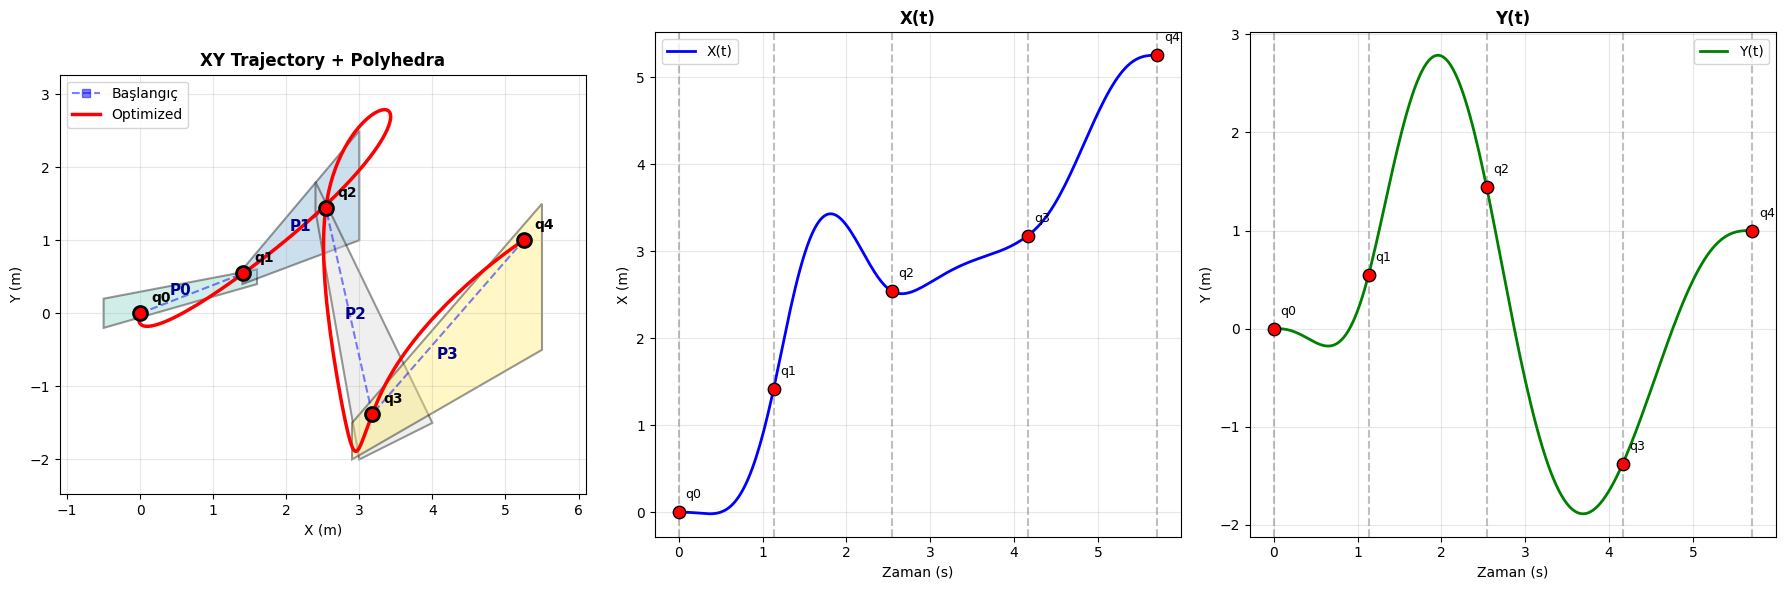

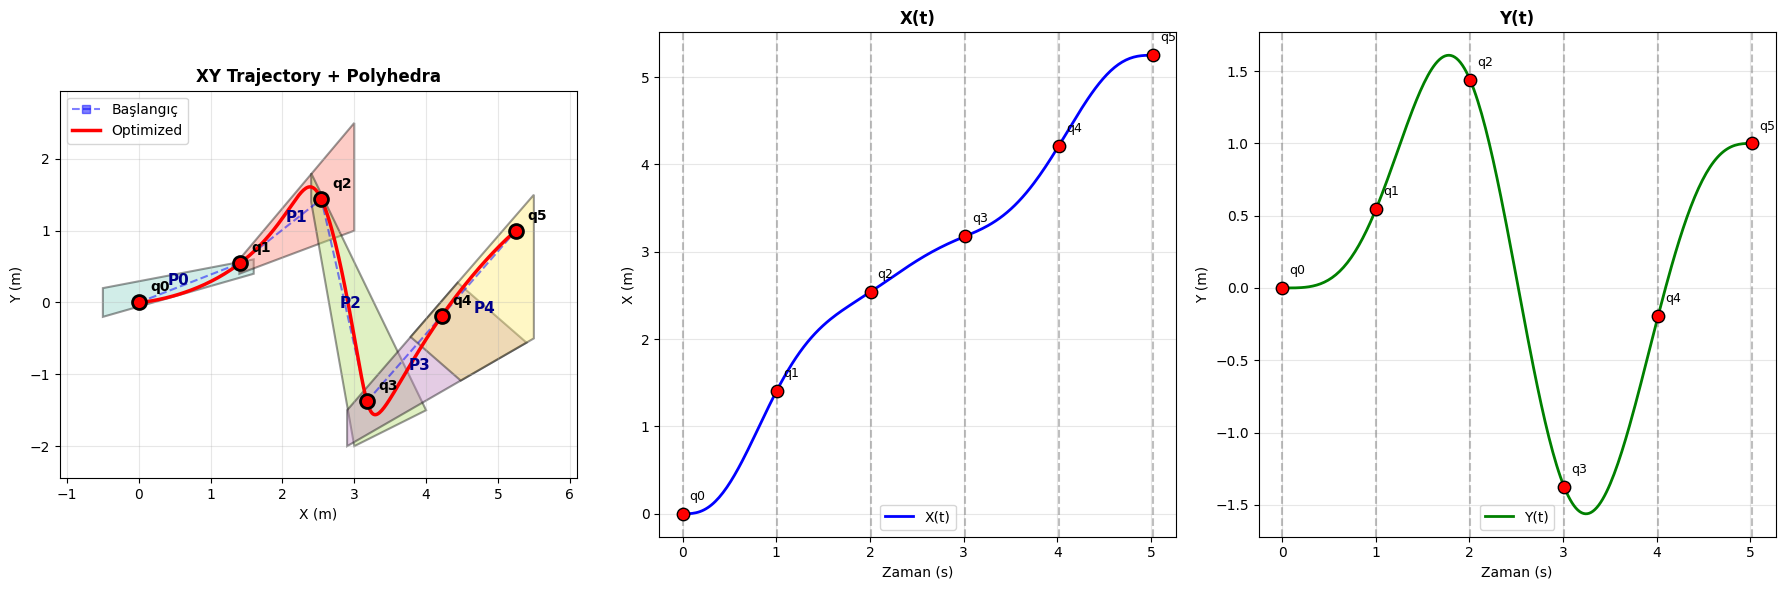

In [4]:
import numpy as np
from matplotlib.path import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

def check_piece_feasibility(opt, piece_idx, polygon, num_samples=50):
    T = opt.Ts[piece_idx]

    d_x = opt.opt[0].dstar[2*opt.S*piece_idx : 2*opt.S*(piece_idx+1)].flatten()
    c_x = opt.opt[0].Abs[piece_idx] @ d_x

    d_y = opt.opt[1].dstar[2*opt.S*piece_idx : 2*opt.S*(piece_idx+1)].flatten()
    c_y = opt.opt[1].Abs[piece_idx] @ d_y

    path = Path(np.array(polygon))

    for t in np.linspace(0, T, num_samples):
        x = sum(c * np.power(t,i) for i, c in enumerate(c_x))
        y = sum(c * np.power(t,i) for i, c in enumerate(c_y))

        if not path.contains_point((x, y)):
            return False, t, (x, y)

    return True, None, None


def check_piece_velocity(opt, piece_idx, v_max, num_samples=50):
    T = opt.Ts[piece_idx]

    d_x = opt.opt[0].dstar[2*opt.S*piece_idx : 2*opt.S*(piece_idx+1)].flatten()
    c_x = opt.opt[0].Abs[piece_idx] @ d_x

    d_y = opt.opt[1].dstar[2*opt.S*piece_idx : 2*opt.S*(piece_idx+1)].flatten()
    c_y = opt.opt[1].Abs[piece_idx] @ d_y

    dc_x = np.array([i * c_x[i] for i in range(1, len(c_x))])
    dc_y = np.array([i * c_y[i] for i in range(1, len(c_y))])

    max_v = 0.0
    max_v_t = 0.0

    for t in np.linspace(0, T, num_samples):
        vx = sum(c * np.power(t,i) for i, c in enumerate(dc_x)) if len(dc_x) > 0 else 0
        vy = sum(c * np.power(t,i) for i, c in enumerate(dc_y)) if len(dc_y) > 0 else 0
        v = np.sqrt(np.power(vx,2) + np.power(vy,2))

        if v > max_v:
            max_v = v
            max_v_t = t

    feasible = max_v <= v_max
    return feasible, max_v, max_v_t if not feasible else None


def check_all_pieces(opt, polygons, v_max, a_max=None, num_samples=50):
    violations = []
    for m in range(opt.M):
        poly_ok, t_viol, point_viol = check_piece_feasibility(opt, m, polygons[m], num_samples)

        if not poly_ok:
            violations.append(m)

        # vel_ok, max_v, t_vel = check_piece_velocity(opt, m, v_max, num_samples)
        # if not vel_ok:
        #     violations.append(m)

    return violations


def split_polygon(polygon, q_prev, q_next, margin=0.1):
    q_prev = np.array(q_prev)
    q_next = np.array(q_next)

    midpoint = (q_prev + q_next) / 2
    direction = q_next - q_prev
    length = np.linalg.norm(direction)
    direction = direction / length

    plane0_point = midpoint - margin * direction
    plane1_point = midpoint + margin * direction

    poly_0 = clip_polygon_by_plane(polygon, plane0_point, direction)
    poly_1 = clip_polygon_by_plane(polygon, plane1_point, -direction)

    return poly_0, poly_1, midpoint


def clip_polygon_by_plane(polygon, plane_point, plane_normal):
    polygon = np.array(polygon)
    plane_point = np.array(plane_point)
    plane_normal = np.array(plane_normal)
    plane_normal = plane_normal / np.linalg.norm(plane_normal)

    clipped = []
    n = len(polygon)
    for i in range(n):
        curr = polygon[i]
        next_p = polygon[(i + 1) % n]

        d_curr = np.dot(curr - plane_point, plane_normal)
        d_next = np.dot(next_p - plane_point, plane_normal)

        if d_curr >= 0:
            clipped.append(curr)

        if d_curr * d_next < 0:
            t = d_curr / (d_curr - d_next)
            intersection = curr + t * (next_p - curr)
            clipped.append(intersection)

    if len(clipped) < 3:
        return polygon

    return clipped



def optimize_with_split(Ts_init, waypoints_init, polygons_init ,max_iterations=5):

    Ts = Ts_init.copy()
    waypoints = waypoints_init.copy()
    polygons = polygons_init.copy()

    for iteration in range(max_iterations):

        opt_waypoint = list(map(np.array,waypoints))
        polyhedra = list(map(polygon_to_polyhedron,polygons))

        opt = DDoPnD([1.0]*(len(waypoints)-1),opt_waypoint,polyhedra,False,False,3)
        T_opt, wp_opt, cost = opt.run()
        if "opt" in locals():
            visualize_results_2d(opt, polyhedra, wp_opt, [])
        # print(T_opt, wp_opt, cost)

        waypoints = [wp_opt[i] for i in range(len(wp_opt))]
        Ts = list(T_opt)

        violations = check_all_pieces(opt, polygons, opt.v_max, opt.a_max)[::-1]

        if len(violations) == 0:return opt, Ts, waypoints, polygons

        piece_idx = violations[0]
        q_prev = waypoints[piece_idx]
        q_next = waypoints[piece_idx + 1]

        poly_0, poly_1,new_waypoint = split_polygon(polygons[piece_idx], q_prev, q_next, 0.5)

        waypoints.insert(piece_idx + 1, new_waypoint)
        Ts[piece_idx] = Ts[piece_idx] / 2
        Ts.insert(piece_idx + 1, Ts[piece_idx] / 2)

        polygons[piece_idx] = poly_1
        polygons.insert(piece_idx + 1, poly_0)

        # current_kappa *= 2
        # current_rho_v *= 1.5
        # current_rho_a *= 1.5

    return opt, Ts, waypoints, polygons

optimize_with_split([1.0]*(len(waypoints)-1),waypoints,polygons,5)
print()
